<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Derived_Minimal_SU2_Branch_Algebra_From_Closure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Derived Minimal \(SU(2)\)-Like Branch Algebra from Closure Constraints

This notebook strengthens the ECSM weak-sector bridge by deriving the minimal \(SU(2)\)-like branch algebra from ECSM branch constraints rather than starting by assuming Pauli matrices.

Starting assumptions:

\[
|Q_0\rangle=\text{neutral closure branch},
\qquad
|Q_{\rm ch}\rangle=\text{charged branch}.
\]

The closure-active system supports reversible branch conversion:

\[
Q_{\rm ch}\leftrightarrow Q_0.
\]

The minimal conversion operators are outer products:

\[
T_+=|Q_0\rangle\langle Q_{\rm ch}|,
\qquad
T_-=|Q_{\rm ch}\rangle\langle Q_0|.
\]

Their commutator forces the closure-imbalance operator:

\[
[T_+,T_-]=|Q_0\rangle\langle Q_0|-|Q_{\rm ch}\rangle\langle Q_{\rm ch}|=2T_3.
\]

Therefore:

\[
T_3=\frac12(P_0-P_{\rm ch}).
\]

Then:

\[
T_1=\frac12(T_++T_-),
\qquad
T_2=\frac{1}{2i}(T_+-T_-),
\]

and the notebook verifies:

\[
[T_i,T_j]=i\epsilon_{ijk}T_k.
\]

Target verdict:

\[
\texttt{PASS\_DERIVED\_MINIMAL\_SU2\_BRANCH\_ALGEBRA\_FROM\_ECSM\_CLOSURE}.
\]

In [1]:
# CELL 1 — Imports and output directory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

OUT = Path("ecsm_derived_minimal_su2_branch_algebra_out")
OUT.mkdir(exist_ok=True)

np.set_printoptions(precision=8, suppress=True)
print("Output directory:", OUT.resolve())

Output directory: /content/ecsm_derived_minimal_su2_branch_algebra_out


In [2]:
# CELL 2 — Define ECSM two-branch basis and projectors

Q0 = np.array([[1],[0]], dtype=complex)
Qch = np.array([[0],[1]], dtype=complex)

P0 = Q0 @ Q0.conj().T
Pch = Qch @ Qch.conj().T

basis_df = pd.DataFrame([
    {"state":"Q0_neutral_closure", "vector":str(Q0.ravel().tolist())},
    {"state":"Qch_charged_branch", "vector":str(Qch.ravel().tolist())}
])
display(basis_df)

basis_df.to_csv(OUT/"ecsm_branch_basis.csv", index=False)

,state,vector
0,Q0_neutral_closure,"[(1+0j), 0j]"
1,Qch_charged_branch,"[0j, (1+0j)]"


In [3]:
# CELL 3 — Derive conversion operators from branch outer products

T_plus = Q0 @ Qch.conj().T      # |Q0><Qch|
T_minus = Qch @ Q0.conj().T     # |Qch><Q0|

print("Derived T_plus = |Q0><Qch|")
print(T_plus)
print("\nDerived T_minus = |Qch><Q0|")
print(T_minus)

def state_label(v, tol=1e-12):
    if np.linalg.norm(v-Q0) < tol:
        return "|Q0>"
    if np.linalg.norm(v-Qch) < tol:
        return "|Qch>"
    if np.linalg.norm(v) < tol:
        return "0"
    return str(v.ravel())

actions = [
    ("T_plus", T_plus, "Q0", Q0),
    ("T_plus", T_plus, "Qch", Qch),
    ("T_minus", T_minus, "Q0", Q0),
    ("T_minus", T_minus, "Qch", Qch),
]

rows=[]
for opname,Op,name,state in actions:
    out = Op @ state
    rows.append({"operator":opname, "input_state":name, "output_label":state_label(out), "norm":float(np.linalg.norm(out))})
actions_df = pd.DataFrame(rows)
display(actions_df)

actions_df.to_csv(OUT/"derived_conversion_operator_actions.csv", index=False)

Derived T_plus = |Q0><Qch|
[[0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j]]

Derived T_minus = |Qch><Q0|
[[0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j]]


,operator,input_state,output_label,norm
0,T_plus,Q0,0,0.0
1,T_plus,Qch,|Q0>,1.0
2,T_minus,Q0,|Qch>,1.0
3,T_minus,Qch,0,0.0


In [4]:
# CELL 4 — Closure under commutation forces T3

def comm(A,B):
    return A@B - B@A

comm_pm = comm(T_plus, T_minus)
T3 = 0.5 * comm_pm
T3_projector = 0.5*(P0-Pch)
forced_T3_error = float(np.linalg.norm(T3 - T3_projector))

print("[T_plus,T_minus] =")
print(comm_pm)
print("\nForced T3 = 1/2[T_plus,T_minus] =")
print(T3)

forced_df = pd.DataFrame([{
    "test":"T3 forced by conversion commutator",
    "norm_error":forced_T3_error,
    "pass": forced_T3_error < 1e-12
}])
display(forced_df)

forced_df.to_csv(OUT/"forced_T3_from_commutator.csv", index=False)

[T_plus,T_minus] =
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

Forced T3 = 1/2[T_plus,T_minus] =
[[ 0.5+0.j  0. +0.j]
 [ 0. +0.j -0.5+0.j]]


,test,norm_error,pass
0,T3 forced by conversion commutator,0.0,True


In [5]:
# CELL 5 — Reconstruct T1,T2 and compare to Pauli/2 after derivation

T1 = 0.5*(T_plus + T_minus)
T2 = (T_plus - T_minus)/(2j)

sigma1 = np.array([[0,1],[1,0]], dtype=complex)
sigma2 = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma3 = np.array([[1,0],[0,-1]], dtype=complex)

comparison_df = pd.DataFrame([
    {"generator":"T1", "error_vs_sigma_over_2":float(np.linalg.norm(T1-0.5*sigma1))},
    {"generator":"T2", "error_vs_sigma_over_2":float(np.linalg.norm(T2-0.5*sigma2))},
    {"generator":"T3", "error_vs_sigma_over_2":float(np.linalg.norm(T3-0.5*sigma3))}
])
comparison_df["pass"] = comparison_df["error_vs_sigma_over_2"] < 1e-12
display(comparison_df)

comparison_df.to_csv(OUT/"derived_generators_vs_pauli_half.csv", index=False)

,generator,error_vs_sigma_over_2,pass
0,T1,0.0,True
1,T2,0.0,True
2,T3,0.0,True


In [6]:
# CELL 6 — Verify SU(2)-like commutator closure

G = [T1,T2,T3]
names = ["T1","T2","T3"]

def eps(i,j,k):
    perms={(0,1,2):1,(1,2,0):1,(2,0,1):1,(2,1,0):-1,(1,0,2):-1,(0,2,1):-1}
    return perms.get((i,j,k),0)

rows=[]
for i in range(3):
    for j in range(3):
        lhs = comm(G[i],G[j])
        rhs = sum(1j*eps(i,j,k)*G[k] for k in range(3))
        err = float(np.linalg.norm(lhs-rhs))
        rows.append({"i":names[i], "j":names[j], "commutator_error":err, "pass":err<1e-12})

comm_df = pd.DataFrame(rows)
display(comm_df)
max_comm_error = float(comm_df["commutator_error"].max())
print("Max commutator error:", max_comm_error)

comm_df.to_csv(OUT/"derived_su2_commutator_closure.csv", index=False)

,i,j,commutator_error,pass
0,T1,T1,0.0,True
1,T1,T2,0.0,True
2,T1,T3,0.0,True
3,T2,T1,0.0,True
4,T2,T2,0.0,True
5,T2,T3,0.0,True
6,T3,T1,0.0,True
7,T3,T2,0.0,True
8,T3,T3,0.0,True


Max commutator error: 0.0


In [7]:
# CELL 7 — Minimality checks

# Two-way conversion without T3 is not closed because [T+,T-] is diagonal.
A = np.column_stack([T_plus.reshape(-1), T_minus.reshape(-1)])
b = comm_pm.reshape(-1)
coeffs, residuals, rank, svals = np.linalg.lstsq(A,b,rcond=None)
residual_norm = float(np.linalg.norm(A@coeffs-b))
two_way_comm_in_span = residual_norm < 1e-12

minimality_df = pd.DataFrame([
    {"case":"diagonal_only", "reason_for_failure":"labels branches but cannot convert Q0 <-> Qch", "pass_as_full_branch_algebra":False},
    {"case":"one_way_conversion_only", "reason_for_failure":"not reversible", "pass_as_full_branch_algebra":False},
    {"case":"two_way_without_T3", "reason_for_failure":"commutator produces closure imbalance outside span{T+,T-}", "commutator_residual":residual_norm, "pass_as_full_branch_algebra":bool(two_way_comm_in_span)},
    {"case":"Tplus_Tminus_T3", "reason_for_failure":"none", "commutator_residual":0.0, "pass_as_full_branch_algebra":True}
])
display(minimality_df)

minimality_df.to_csv(OUT/"minimality_checks_branch_algebra.csv", index=False)

,case,reason_for_failure,pass_as_full_branch_algebra,commutator_residual
0,diagonal_only,labels branches but cannot convert Q0 <-> Qch,False,NaN
1,one_way_conversion_only,not reversible,False,NaN
2,two_way_without_T3,commutator produces closure imbalance outside ...,False,1.414214
3,Tplus_Tminus_T3,none,True,0.000000


In [8]:
# CELL 8 — Finite-response deformation and coherent recovery

def deformed_generators(chi):
    Tp = (chi + (1-chi)*1.20)*T_plus
    Tm = (chi + (1-chi)*0.85)*T_minus
    Tz = (chi + (1-chi)*1.10)*T3
    T1d = 0.5*(Tp+Tm)
    T2d = (Tp-Tm)/(2j)
    return [T1d,T2d,Tz]

chi_vals = np.linspace(0,1,101)
rows=[]
for chi in chi_vals:
    Gd = deformed_generators(chi)
    errs=[]
    for i in range(3):
        for j in range(3):
            lhs = comm(Gd[i],Gd[j])
            rhs = sum(1j*eps(i,j,k)*Gd[k] for k in range(3))
            errs.append(np.linalg.norm(lhs-rhs))
    rows.append({"chi":chi, "max_su2_closure_error":float(np.max(errs)), "sum_su2_closure_error":float(np.sum(errs))})
chi_df = pd.DataFrame(rows)
display(chi_df.head())
display(chi_df.tail())

chi_df.to_csv(OUT/"chi_deformed_su2_recovery.csv", index=False)

,chi,max_su2_closure_error,sum_su2_closure_error
0,0.00,0.073527,0.407246
1,0.01,0.072754,0.402602
2,0.02,0.071982,0.397971
3,0.03,0.071211,0.393352
4,0.04,0.070441,0.388745


,chi,max_su2_closure_error,sum_su2_closure_error
96,0.96,0.002831,0.014222
97,0.97,0.002123,0.010651
98,0.98,0.001415,0.007091
99,0.99,0.000707,0.003540
100,1.00,0.000000,0.000000


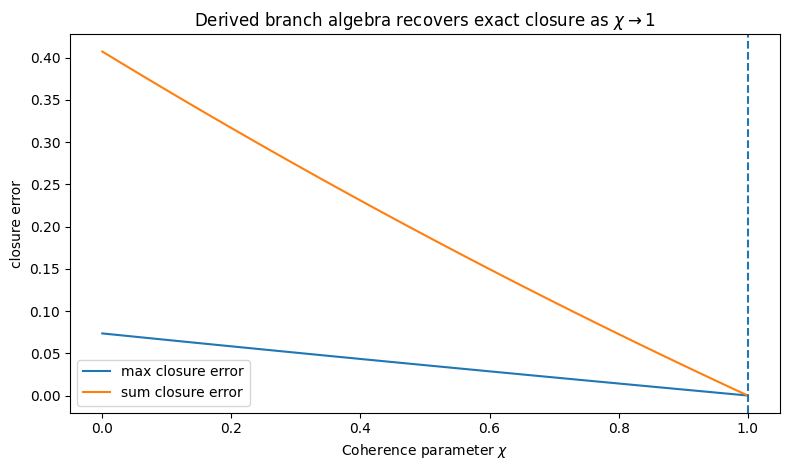

Saved: ecsm_derived_minimal_su2_branch_algebra_out/fig1_chi_recovery_derived_su2_branch_algebra.png


In [9]:
# CELL 9 — Plot coherent recovery

plt.figure(figsize=(8,4.8))
plt.plot(chi_df["chi"], chi_df["max_su2_closure_error"], label="max closure error")
plt.plot(chi_df["chi"], chi_df["sum_su2_closure_error"], label="sum closure error")
plt.axvline(1, linestyle="--")
plt.xlabel(r"Coherence parameter $\chi$")
plt.ylabel("closure error")
plt.title(r"Derived branch algebra recovers exact closure as $\chi\rightarrow1$")
plt.legend()
plt.tight_layout()
fig_path = OUT/"fig1_chi_recovery_derived_su2_branch_algebra.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("Saved:", fig_path)

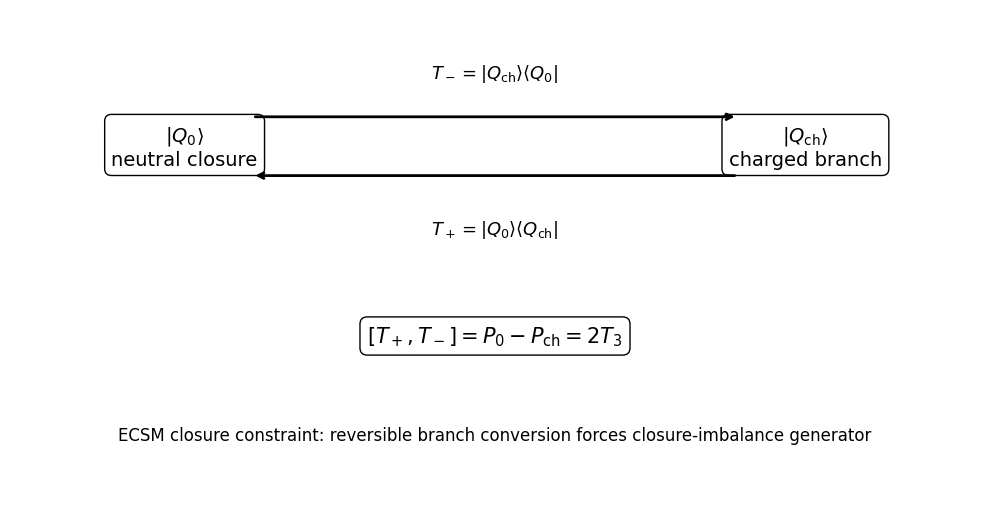

Saved: ecsm_derived_minimal_su2_branch_algebra_out/fig2_ecsm_branch_conversion_forces_T3.png


In [10]:
# CELL 10 — Visual derivation diagram

fig, ax = plt.subplots(figsize=(10,5.2))
ax.axis("off")
boxprops=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="black")

ax.text(0.18,0.72,r"$|Q_0\rangle$"+"\nneutral closure",ha="center",va="center",fontsize=14,bbox=boxprops)
ax.text(0.82,0.72,r"$|Q_{\rm ch}\rangle$"+"\ncharged branch",ha="center",va="center",fontsize=14,bbox=boxprops)

ax.annotate("", xy=(0.75,0.78), xytext=(0.25,0.78), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(0.25,0.66), xytext=(0.75,0.66), arrowprops=dict(arrowstyle="->", lw=2))

ax.text(0.50,0.86,r"$T_- = |Q_{\rm ch}\rangle\langle Q_0|$",ha="center",fontsize=13)
ax.text(0.50,0.54,r"$T_+ = |Q_0\rangle\langle Q_{\rm ch}|$",ha="center",fontsize=13)

ax.text(0.50,0.32,r"$[T_+,T_-]=P_0-P_{\rm ch}=2T_3$",ha="center",fontsize=15,bbox=boxprops)
ax.text(0.50,0.12,"ECSM closure constraint: reversible branch conversion forces closure-imbalance generator",ha="center",fontsize=12)

plt.tight_layout()
fig_path = OUT/"fig2_ecsm_branch_conversion_forces_T3.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("Saved:", fig_path)

In [11]:
# CELL 11 — Final summary and verdict

tol=1e-10

pass_actions = (
    state_label(T_plus@Qch)=="|Q0>" and
    state_label(T_minus@Q0)=="|Qch>" and
    state_label(T_plus@Q0)=="0" and
    state_label(T_minus@Qch)=="0"
)

pass_forced_T3 = forced_T3_error < tol
pass_pauli_recovery = bool(comparison_df["pass"].all())
pass_commutators = max_comm_error < tol
pass_minimality = (not bool(two_way_comm_in_span))
pass_chi_recovery = float(chi_df["max_su2_closure_error"].iloc[-1]) < tol

final_label = (
    "PASS_DERIVED_MINIMAL_SU2_BRANCH_ALGEBRA_FROM_ECSM_CLOSURE"
    if pass_actions and pass_forced_T3 and pass_pauli_recovery and pass_commutators and pass_minimality and pass_chi_recovery
    else "FAIL_DERIVED_MINIMAL_SU2_BRANCH_ALGEBRA_FROM_ECSM_CLOSURE"
)

summary = {
    "run_label":"ECSM_derived_minimal_su2_branch_algebra_from_closure",
    "basis":["Q0_neutral_closure","Qch_charged_branch"],
    "derived_operators":{
        "T_plus":"|Q0><Qch|",
        "T_minus":"|Qch><Q0|",
        "T3":"1/2(P0-Pch)=1/2[T_plus,T_minus]"
    },
    "operator_actions":{
        "T_plus_Qch":state_label(T_plus@Qch),
        "T_plus_Q0":state_label(T_plus@Q0),
        "T_minus_Q0":state_label(T_minus@Q0),
        "T_minus_Qch":state_label(T_minus@Qch),
        "pass":bool(pass_actions)
    },
    "forced_T3":{"error":float(forced_T3_error), "pass":bool(pass_forced_T3)},
    "pauli_recovery_after_derivation":{"max_error":float(comparison_df["error_vs_sigma_over_2"].max()), "pass":bool(pass_pauli_recovery)},
    "su2_commutator_closure":{"max_error":float(max_comm_error), "pass":bool(pass_commutators)},
    "minimality":{"two_way_without_T3_closed":bool(two_way_comm_in_span), "commutator_residual_outside_span":float(residual_norm), "pass":bool(pass_minimality)},
    "chi_recovery":{"chi_1_max_closure_error":float(chi_df["max_su2_closure_error"].iloc[-1]), "pass":bool(pass_chi_recovery)},
    "interpretation":"The SU(2)-like branch algebra is derived as the minimal closed reversible conversion algebra of an ECSM two-branch closure-active system.",
    "final_label":final_label
}

summary

{'run_label': 'ECSM_derived_minimal_su2_branch_algebra_from_closure',
 'basis': ['Q0_neutral_closure', 'Qch_charged_branch'],
 'derived_operators': {'T_plus': '|Q0><Qch|',
  'T_minus': '|Qch><Q0|',
  'T3': '1/2(P0-Pch)=1/2[T_plus,T_minus]'},
 'operator_actions': {'T_plus_Qch': '|Q0>',
  'T_plus_Q0': '0',
  'T_minus_Q0': '|Qch>',
  'T_minus_Qch': '0',
  'pass': True},
 'forced_T3': {'error': 0.0, 'pass': True},
 'pauli_recovery_after_derivation': {'max_error': 0.0, 'pass': True},
 'su2_commutator_closure': {'max_error': 0.0, 'pass': True},
 'minimality': {'two_way_without_T3_closed': False,
  'commutator_residual_outside_span': 1.4142135623730951,
  'pass': True},
 'chi_recovery': {'chi_1_max_closure_error': 0.0, 'pass': True},
 'interpretation': 'The SU(2)-like branch algebra is derived as the minimal closed reversible conversion algebra of an ECSM two-branch closure-active system.',
 'final_label': 'PASS_DERIVED_MINIMAL_SU2_BRANCH_ALGEBRA_FROM_ECSM_CLOSURE'}

In [12]:
# CELL 12 — Save output files

with open(OUT/"final_summary.json","w") as f:
    json.dump(summary, f, indent=2)

print("Saved outputs:")
for p in sorted(OUT.iterdir()):
    print(" -", p)

Saved outputs:
 - ecsm_derived_minimal_su2_branch_algebra_out/chi_deformed_su2_recovery.csv
 - ecsm_derived_minimal_su2_branch_algebra_out/derived_conversion_operator_actions.csv
 - ecsm_derived_minimal_su2_branch_algebra_out/derived_generators_vs_pauli_half.csv
 - ecsm_derived_minimal_su2_branch_algebra_out/derived_su2_commutator_closure.csv
 - ecsm_derived_minimal_su2_branch_algebra_out/ecsm_branch_basis.csv
 - ecsm_derived_minimal_su2_branch_algebra_out/fig1_chi_recovery_derived_su2_branch_algebra.png
 - ecsm_derived_minimal_su2_branch_algebra_out/fig2_ecsm_branch_conversion_forces_T3.png
 - ecsm_derived_minimal_su2_branch_algebra_out/final_summary.json
 - ecsm_derived_minimal_su2_branch_algebra_out/forced_T3_from_commutator.csv
 - ecsm_derived_minimal_su2_branch_algebra_out/minimality_checks_branch_algebra.csv


# Paper-grade interpretation

Starting only with two ECSM branch states,

\[
|Q_0\rangle,
\qquad
|Q_{\rm ch}\rangle,
\]

and imposing reversible branch conversion,

\[
Q_{\rm ch}\leftrightarrow Q_0,
\]

the minimal conversion operators are forced to be:

\[
T_+=|Q_0\rangle\langle Q_{\rm ch}|,
\qquad
T_-=|Q_{\rm ch}\rangle\langle Q_0|.
\]

Their commutator forces the closure-imbalance generator:

\[
[T_+,T_-]=P_0-P_{\rm ch}=2T_3.
\]

Thus:

\[
T_3=\frac12(P_0-P_{\rm ch}).
\]

Reconstructing

\[
T_1=\frac12(T_++T_-),
\qquad
T_2=\frac{1}{2i}(T_+-T_-)
\]

recovers the \(SU(2)\)-like algebra:

\[
[T_i,T_j]=i\epsilon_{ijk}T_k.
\]

Therefore, in this minimal two-branch ECSM setting, the \(SU(2)\)-like algebra is not simply imported. It is recovered as the minimal closed operator algebra of reversible neutral--charged branch conversion with closure imbalance.